In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
import wrds

In [3]:
db = wrds.Connection()

Loading library list...
Done


In [4]:
query = """
SELECT
    permno,
    date,
    ret
FROM crsp.msf
WHERE date >= '1956-01-01'
  AND date <= '1967-12-31'
"""

In [5]:
msf_5767 = db.raw_sql(query)

db.close()

In [6]:
msf_5767

,permno,date,ret
0,10006,1956-01-31,-0.04428
1,10014,1956-01-31,0.083333
2,10022,1956-01-31,0.0
3,10030,1956-01-31,-0.015337
4,10057,1956-01-31,-0.037313
...,...,...,...
228991,68523,1967-12-29,0.481481
228992,76151,1967-12-29,-0.072165
228993,84751,1967-12-29,<NA>
228994,84911,1967-12-29,0.057971


In [7]:
msf_5767['date'] = pd.to_datetime(msf_5767['date'])

In [8]:
msf_5767 = msf_5767.sort_values(['permno', 'date']).reset_index(drop=True)

In [9]:
msf_5767.duplicated(subset=['permno', 'date']).any()

False

In [10]:
# explicitly check for missing months per permno before lagging
msf_5767['month'] = msf_5767['date'].dt.to_period('M')
msf_5767

,permno,date,ret,month
0,10006,1956-01-31,-0.04428,1956-01
1,10006,1956-02-29,-0.001931,1956-02
2,10006,1956-03-29,0.041257,1956-03
3,10006,1956-04-30,-0.026415,1956-04
4,10006,1956-05-31,-0.054264,1956-05
...,...,...,...,...
228991,86239,1967-08-31,-0.029412,1967-08
228992,86239,1967-09-29,-0.099394,1967-09
228993,86239,1967-10-31,-0.102041,1967-10
228994,86239,1967-11-30,0.037879,1967-11


In [11]:
msf_5767['month_diff'] = (
    msf_5767
    .groupby('permno')['month']
    .diff()
    .apply(lambda x: x.n if pd.notnull(x) else None)
)


In [12]:
msf_5767['mom12m'] = (
    msf_5767
    .groupby('permno')['ret']
    .apply(lambda s: (1.0+s).rolling(12, min_periods=12).apply(np.prod, raw=True) - 1.0)
    .reset_index(level=0, drop=True)
    .shift(1)
)

In [13]:
msf_5767['mom12m'].describe()


count    191251.000000
mean          0.184129
std           0.492868
min          -0.940171
25%          -0.073474
50%           0.103449
75%           0.325582
max          28.823538
Name: mom12m, dtype: float64

In [14]:
len(msf_5767)

228996

In [15]:
msf_5767 = msf_5767.sort_values(['permno', 'date']).reset_index(drop=True)


In [16]:
msf_5767['mom1m'] = (
    msf_5767
    .groupby('permno')['ret']
    .shift(1)
)

In [17]:
msf_5767[['ret', 'mom1m']].head(5)


,ret,mom1m
0,-0.04428,<NA>
1,-0.001931,-0.04428
2,0.041257,-0.001931
3,-0.026415,0.041257
4,-0.054264,-0.026415


In [18]:
msf_5767 = msf_5767.sort_values(['permno', 'date']).reset_index(drop=True)

In [19]:
import numpy as np

msf_5767['mom6m'] = (
    msf_5767
    .groupby('permno')['ret']
    .apply(lambda s: (1.0 + s).rolling(6, min_periods=6).apply(np.prod, raw=True) - 1.0)
    .reset_index(level=0, drop=True)
    .shift(-1)
)


In [20]:
msf_5767

,permno,date,ret,month,month_diff,mom12m,mom1m,mom6m
0,10006,1956-01-31,-0.04428,1956-01,NaN,NaN,<NA>,NaN
1,10006,1956-02-29,-0.001931,1956-02,1.0,NaN,-0.04428,NaN
2,10006,1956-03-29,0.041257,1956-03,1.0,NaN,-0.001931,NaN
3,10006,1956-04-30,-0.026415,1956-04,1.0,NaN,0.041257,NaN
4,10006,1956-05-31,-0.054264,1956-05,1.0,NaN,-0.026415,-0.064522
...,...,...,...,...,...,...,...,...
228991,86239,1967-08-31,-0.029412,1967-08,1.0,0.641780,-0.028571,0.127509
228992,86239,1967-09-29,-0.099394,1967-09,1.0,0.703932,-0.029412,-0.083968
228993,86239,1967-10-31,-0.102041,1967-10,1.0,0.666578,-0.099394,-0.029463
228994,86239,1967-11-30,0.037879,1967-11,1.0,0.434806,-0.102041,-0.199379


In [21]:
msf_5767_mom = msf_5767.dropna(
    subset=['mom1m', 'mom6m', 'mom12m']
).reset_index(drop=True)


In [22]:
msf_5767_mom.sort_values(['date','permno']).reset_index(drop=True)

,permno,date,ret,month,month_diff,mom12m,mom1m,mom6m
0,10006,1957-01-31,0.064378,1957-01,1.0,-0.080746,0.044843,8.332949e-02
1,10014,1957-01-31,0.095238,1957-01,1.0,-0.125002,-0.086957,-1.600010e-01
2,10022,1957-01-31,0.102041,1957-01,1.0,-0.162564,-0.060377,-4.228734e-02
3,10030,1957-01-31,-0.047091,1957-01,1.0,0.184249,0.044633,3.359145e-02
4,10057,1957-01-31,-0.090062,1957-01,1.0,0.285358,0.086667,1.656409e-02
...,...,...,...,...,...,...,...,...
185668,68195,1967-11-30,-0.009615,1967-11,1.0,0.466818,-0.045872,5.180932e-02
185669,68523,1967-11-30,0.08,1967-11,1.0,0.829268,-0.013158,4.117650e-01
185670,76151,1967-11-30,0.114943,1967-11,1.0,1.071428,-0.13,6.574262e-07
185671,84911,1967-11-30,-0.067568,1967-11,1.0,2.288890,0.193548,1.281249e+00


(array([3.85000e+02, 1.92310e+04, 1.10033e+05, 4.47950e+04, 7.40700e+03,
        2.21300e+03, 8.12000e+02, 3.52000e+02, 1.76000e+02, 9.40000e+01,
        5.50000e+01, 3.20000e+01, 2.90000e+01, 1.80000e+01, 9.00000e+00,
        5.00000e+00, 6.00000e+00, 5.00000e+00, 1.00000e+00, 1.00000e+00,
        1.00000e+00, 4.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
        0.00000e+00, 2.00000e+00, 0.00000e+00, 0.00000e+00, 1.00000e+00,
        1.00000e+00, 1.00000e+00, 0.00000e+00, 1.00000e+00, 0.00000e+00,
        0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00,
        0.00000e+00, 0.00000e+00, 1.00000e+00, 0.00000e+00, 0.00000e+00,
        1.00000e+00, 0.00000e+00, 0.00000e+00, 0.00000e+00, 1.00000e+00]),
 array([-0.86956524, -0.52434776, -0.17913028,  0.16608719,  0.51130467,
         0.85652215,  1.20173963,  1.54695711,  1.89217459,  2.23739206,
         2.58260954,  2.92782702,  3.2730445 ,  3.61826198,  3.96347946,
         4.30869693,  4.65391441,  4.99913189,  5

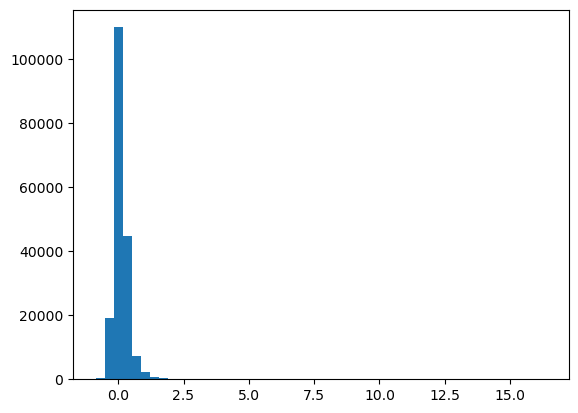

In [23]:
plt.hist(msf_5767_mom['mom6m'], bins=50)

In [25]:
import os
print(os.getcwd())  # 获取当前工作目录
print(os.listdir()) # 查看当前目录下有哪些文件

/Users/zixuanzhou/Library/CloudStorage/OneDrive-Personal/MasterJHU/26Spring/SP805Industrial/datashare
['datashare.csv', 'Features.ipynb', 'readme.txt']


In [26]:
df = pd.read_csv('datashare.csv')

(array([3.109000e+03, 3.358400e+04, 1.135070e+05, 2.511540e+05,
        5.317370e+05, 1.056777e+06, 1.039848e+06, 4.669360e+05,
        2.061120e+05, 1.021420e+05, 5.636600e+04, 3.511700e+04,
        2.123200e+04, 1.368600e+04, 8.748000e+03, 6.327000e+03,
        3.552000e+03, 2.462000e+03, 1.526000e+03, 1.672000e+03,
        1.205000e+03, 7.200000e+02, 4.720000e+02, 4.060000e+02,
        2.730000e+02, 2.140000e+02, 1.760000e+02, 2.200000e+02,
        6.600000e+01, 5.100000e+01, 1.650000e+02, 8.900000e+01,
        1.580000e+02, 1.800000e+01, 2.000000e+01, 1.700000e+01,
        1.200000e+01, 1.200000e+01, 1.400000e+01, 8.900000e+01,
        5.000000e+00, 9.000000e+00, 9.000000e+00, 6.000000e+00,
        6.000000e+00, 3.000000e+00, 4.000000e+00, 4.000000e+00,
        7.000000e+00, 8.300000e+01]),
 array([-1.        , -0.82933333, -0.65866667, -0.488     , -0.31733333,
        -0.14666667,  0.024     ,  0.19466667,  0.36533333,  0.536     ,
         0.70666667,  0.87733334,  1.048     ,  

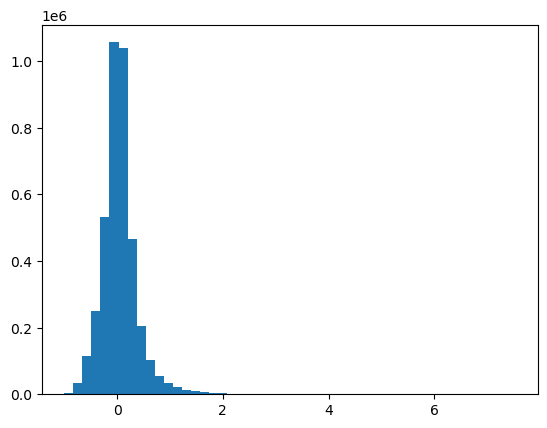

In [27]:
plt.hist(df['mom6m'], bins=50)

## bid ask spread